# GP Hybrid PyTorch Organized — Balanced Dataset Version

هذه نسخة مشروعك كاملة بنفس ترتيب الملف تقريبًا، لكن تم تعديل جزء الداتا عشان ما نستخدم `Test-A` و `Test-B` غير المتوازنة.  
الكود الآن يأخذ الصور من مجلد `Train` فقط ثم يقسمها داخليًا إلى:

- 70% Training
- 15% Validation
- 15% Testing

مع `stratify` عشان كل قسم يحتوي كل الكلاسات الخمسة بنفس التوزيع تقريبًا.


In [1]:
# Import required libraries for file handling and visualization
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import seaborn as sns
from collections import Counter

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models

# Metrics
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Setup device for CUDA support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================


Using device: cpu


In [5]:
# 1. Path Setup & Balanced Dataset Split
# ==========================================
# ملاحظة:
# لا نستخدم Test-A و Test-B هنا لأن التوزيع عندك كان غير متوازن وناقص كلاسات.
# نستخدم Train فقط ونقسمه داخليًا إلى Train / Validation / Test بشكل متوازن.

base_path = os.path.abspath("../data/datasets")
train_path = os.path.join(base_path, "Train")
train_path = os.path.join(base_path, "Train")

print("base_path =", os.path.abspath(base_path))
print("train_path =", os.path.abspath(train_path))

print("Folders inside Train:", os.listdir(train_path))

# Collect all image paths and labels from Train folder only
image_paths = []
labels = []

classes = sorted([
    c for c in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, c))
])

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            image_paths.append(img_path)
            labels.append(class_name)

print("Total images:", len(image_paths))
print("Number of classes:", len(classes))

print("\nClass names:")
for c in classes:
    print(c)

print("\nOriginal class distribution:")
print(Counter(labels))

# Stratified split:
# 70% train, 15% validation, 15% test
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("\nTraining images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))

print("\nTrain distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

print("\nTest distribution:")
print(Counter(test_labels))


base_path = /Users/remazkh/Downloads/GP_project-master/data/datasets
train_path = /Users/remazkh/Downloads/GP_project-master/data/datasets/Train
Folders inside Train: ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']
Total images: 10175
Number of classes: 5

Class names:
Basophil
Eosinophil
Lymphocyte
Monocyte
Neutrophil

Original class distribution:
Counter({'Neutrophil': 6231, 'Lymphocyte': 2427, 'Eosinophil': 744, 'Monocyte': 561, 'Basophil': 212})

Training images: 7122
Validation images: 1526
Testing images: 1527

Train distribution:
Counter({'Neutrophil': 4361, 'Lymphocyte': 1699, 'Eosinophil': 521, 'Monocyte': 393, 'Basophil': 148})

Validation distribution:
Counter({'Neutrophil': 935, 'Lymphocyte': 364, 'Eosinophil': 111, 'Monocyte': 84, 'Basophil': 32})

Test distribution:
Counter({'Neutrophil': 935, 'Lymphocyte': 364, 'Eosinophil': 112, 'Monocyte': 84, 'Basophil': 32})


In [6]:
# Base transform to mimic Keras image_dataset_from_directory (loads and resizes)
# ملاحظة مهمة:
# أضفنا Normalize لأنه مطلوب مع EfficientNetV2 و ConvNeXt المدربة مسبقًا على ImageNet.

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:
# Custom Dataset بدل ImageFolder عشان نستخدم التقسيم الجديد train_imgs / val_imgs / test_imgs

class WBCCustomDataset(Dataset):
    def __init__(self, image_paths, labels, class_names, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_names = class_names
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_name = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[label_name]

        return image, label


# PyTorch Datasets for initial inspection
train_dataset = WBCCustomDataset(train_imgs, train_labels, classes, transform=base_transform)
val_dataset = WBCCustomDataset(val_imgs, val_labels, classes, transform=base_transform)
test_dataset = WBCCustomDataset(test_imgs, test_labels, classes, transform=base_transform)

train_loader_initial = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader_initial = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Number of classes:", len(classes))

print("\nClass names:")
for c in classes:
    print(c)

class_names = classes


Number of classes: 5

Class names:
Basophil
Eosinophil
Lymphocyte
Monocyte
Neutrophil


In [8]:
# Count number of images in each class
class_counts = Counter(labels)

for class_name in classes:
    print(class_name, ":", class_counts[class_name], "images")

# ==========================================


Basophil : 212 images
Eosinophil : 744 images
Lymphocyte : 2427 images
Monocyte : 561 images
Neutrophil : 6231 images


In [9]:
# 2. Visualizations & HSI Preprocessing 
# ==========================================


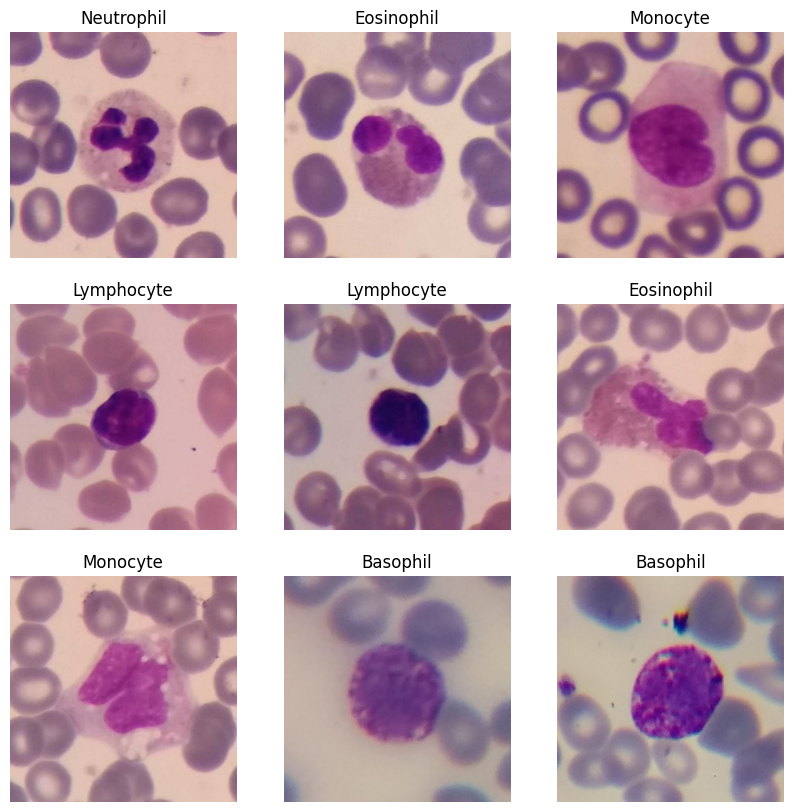

In [10]:
# Display sample images from the dataset
plt.figure(figsize=(10, 10))

for i in range(9):
    class_name = random.choice(classes)
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()


In [11]:
# Check sample image sizes
image_sizes = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    images = os.listdir(class_path)[:5]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Sample image sizes:")
print(image_sizes[:10])


Sample image sizes:
[(575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575)]


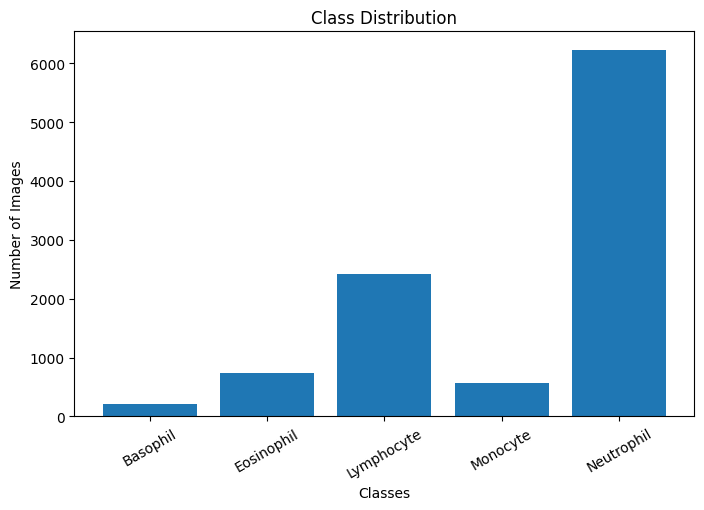

In [12]:
# Plot dataset class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()


In [13]:
# Check for imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())

if max_count - min_count > 0:
    print("Dataset has class imbalance")
else:
    print("Dataset is balanced")


Dataset has class imbalance


In [14]:
# Already collected and split image paths manually
print("Total images:", len(image_paths))
print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))


Total images: 10175
Training images: 7122
Validation images: 1526
Testing images: 1527


In [15]:
# HSI Logic
def rgb_to_hsi(img):
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    I = (R + G + B) / 3.0

    min_rgb = np.minimum(np.minimum(R, G), B)

    S = np.zeros_like(I)
    denom = R + G + B
    mask = denom > 1e-8
    S[mask] = 1 - (3 * min_rgb[mask] / denom[mask])

    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8

    theta = np.arccos(np.clip(num / den, -1, 1))

    H = np.zeros_like(I)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]
    H = H / (2 * np.pi)

    return np.stack([H, S, I], axis=-1)


def hsi_to_rgb(hsi):
    H = hsi[:, :, 0] * 2 * np.pi
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]

    R, G, B = np.zeros_like(I), np.zeros_like(I), np.zeros_like(I)

    mask1 = (H >= 0) & (H < 2 * np.pi / 3)
    B[mask1] = I[mask1] * (1 - S[mask1])
    R[mask1] = I[mask1] * (1 + (S[mask1] * np.cos(H[mask1])) / (np.cos(np.pi / 3 - H[mask1]) + 1e-8))
    G[mask1] = 3 * I[mask1] - (R[mask1] + B[mask1])

    mask2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[mask2] - 2 * np.pi / 3
    R[mask2] = I[mask2] * (1 - S[mask2])
    G[mask2] = I[mask2] * (1 + (S[mask2] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + 1e-8))
    B[mask2] = 3 * I[mask2] - (R[mask2] + G[mask2])

    mask3 = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[mask3] - 4 * np.pi / 3
    G[mask3] = I[mask3] * (1 - S[mask3])
    B[mask3] = I[mask3] * (1 + (S[mask3] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + 1e-8))
    R[mask3] = 3 * I[mask3] - (G[mask3] + B[mask3])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)

    return (rgb * 255).astype(np.uint8)


def preprocess_image_hsi(img_path, size=(224, 224)):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    hsi = rgb_to_hsi(img)

    H, S, I = hsi[:, :, 0], hsi[:, :, 1], hsi[:, :, 2]

    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)
    I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0

    hsi_eq = np.stack([H, S, I_eq], axis=-1)

    img_eq = hsi_to_rgb(hsi_eq)

    return img_eq.astype("float32") / 255.0


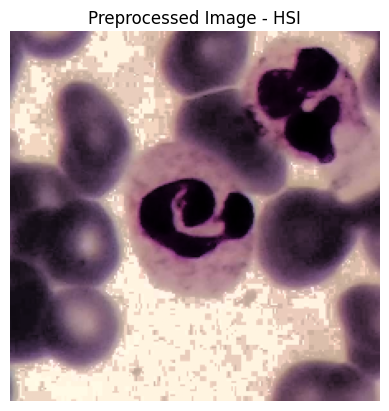

In [16]:
# Optional HSI arrays
# ملاحظة:
# هذا الجزء قد يأخذ وقت وذاكرة عالية لأنه يحول كل الصور إلى numpy arrays.
# إذا جهازك بطيء، تقدرين تخلينه commented.

# X_train = np.array([preprocess_image_hsi(p) for p in train_imgs])
# X_val   = np.array([preprocess_image_hsi(p) for p in val_imgs])
# X_test  = np.array([preprocess_image_hsi(p) for p in test_imgs])

# print("X_train shape:", X_train.shape)
# print("X_val shape:", X_val.shape)
# print("X_test shape:", X_test.shape)

sample = preprocess_image_hsi(train_imgs[0])

plt.imshow(sample)
plt.title("Preprocessed Image - HSI")
plt.axis("off")
plt.show()


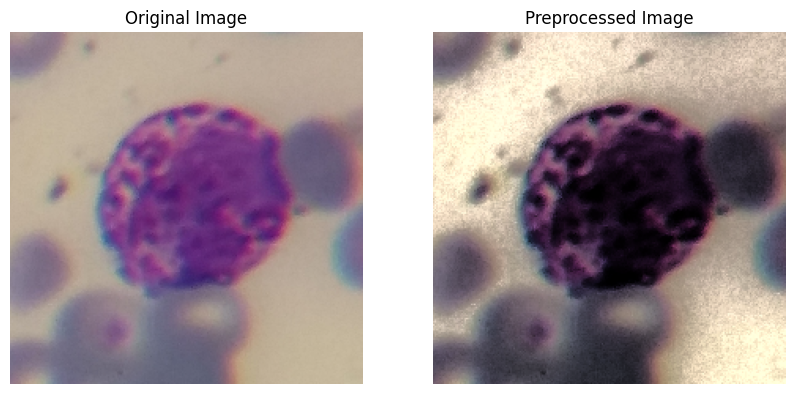

In [17]:
sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224))

processed = preprocess_image_hsi(sample_image_path)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()


In [18]:
# ==========================================
# 3. Data Augmentation & Loaders
# ==========================================

# PyTorch equivalent of your TF Data Augmentation sequence
# عدلنا rotation من 36 إلى 15 لأنه كان قوي وقد يسبب overfitting/ضعف تعميم.
# أضفنا Normalize لأنه ضروري مع pretrained models.

data_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, scale=(0.9, 1.1)),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

augmented_train_dataset = WBCCustomDataset(
    train_imgs,
    train_labels,
    classes,
    transform=data_augmentation
)

val_dataset = WBCCustomDataset(
    val_imgs,
    val_labels,
    classes,
    transform=test_transform
)

test_dataset = WBCCustomDataset(
    test_imgs,
    test_labels,
    classes,
    transform=test_transform
)

train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

class_names = classes

print("Class names:", class_names)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Train batches: 223
Val batches: 48
Test batches: 48


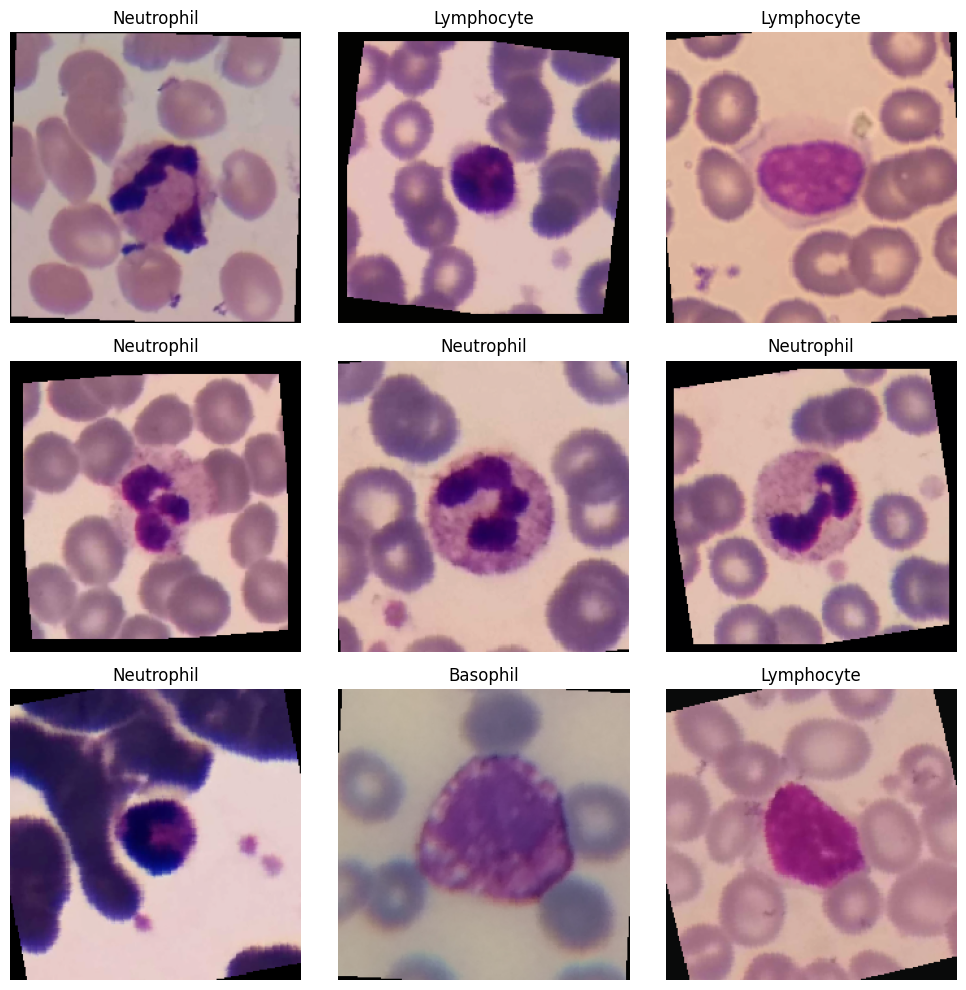

In [19]:
# Plot augmented samples
# نحتاج unnormalize للعرض فقط.

def unnormalize_image(tensor_img):
    img = tensor_img.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img


plt.figure(figsize=(10, 10))
data_iter = iter(train_loader)
images, labels_batch = next(data_iter)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)

    img = unnormalize_image(images[i])

    plt.imshow(img)
    plt.title(class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================


In [20]:
# Class weights to handle imbalance
# هذا يعطي اهتمام أكثر للكلاسات القليلة مثل Basophil.

train_label_indices = [classes.index(lbl) for lbl in train_labels]
train_counts = Counter(train_label_indices)

num_classes = len(class_names)
total_samples = len(train_label_indices)

class_weights = []

for i in range(num_classes):
    class_weights.append(total_samples / (num_classes * train_counts[i]))

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Train counts:", train_counts)
print("Class weights:", class_weights)


Train counts: Counter({4: 4361, 2: 1699, 1: 521, 3: 393, 0: 148})
Class weights: tensor([9.6243, 2.7340, 0.8384, 3.6244, 0.3266])


In [21]:
# 4. Model Definition (Hybrid)
# ==========================================
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()

        # Base 1: EfficientNetV2_S
        self.eff = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        eff_out_features = self.eff.classifier[1].in_features
        self.eff.classifier = nn.Identity()

        # Base 2: ConvNeXt_Tiny
        self.conv = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        conv_out_features = self.conv.classifier[2].in_features
        self.conv.classifier[2] = nn.Identity()

        # Freeze both bases initially
        for param in self.eff.parameters():
            param.requires_grad = False

        for param in self.conv.parameters():
            param.requires_grad = False

        # Fusion head matching TF dense layers
        self.fc1 = nn.Linear(eff_out_features + conv_out_features, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        eff_features = self.eff(x)
        conv_features = self.conv(x)

        fused_features = torch.cat((eff_features, conv_features), dim=1)

        x = self.fc1(fused_features)
        x = self.relu(x)
        x = self.dropout(x)
        outputs = self.fc2(x)

        return outputs


Number of classes: 5
Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [22]:
# Re-initialize the model
hybrid_model = HybridModel(num_classes).to(device)


In [23]:
# Optimizer, scheduler, and weighted loss
# أضفنا weight=class_weights لعلاج عدم توازن الداتا.

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(hybrid_model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)


/opt/anaconda3/envs/gp_tf/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [25]:
# Training loop abstraction to handle Keras-like epochs and history tracking
def train_eval_loop(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs, save_name="best_hybrid_model.pth"):
    history = {'accuracy': [], 'loss': [], 'val_accuracy': [], 'val_loss': []}

    best_val_acc = 0.0
    patience = 3
    trigger_times = 0

    for epoch in range(epochs):
        model.train()

        running_loss, correct, total = 0.0, 0, 0

        for images, labels_batch in train_loader:
            images, labels_batch = images.to(device), labels_batch.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)

            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()

        val_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels_batch in val_loader:
                images, labels_batch = images.to(device), labels_batch.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels_batch)

                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs.data, 1)

                v_total += labels_batch.size(0)
                v_correct += (predicted == labels_batch).sum().item()

        val_loss = val_loss / v_total
        val_acc = v_correct / v_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} - "
            f"loss: {train_loss:.4f} - "
            f"accuracy: {train_acc:.4f} - "
            f"val_loss: {val_loss:.4f} - "
            f"val_accuracy: {val_acc:.4f}"
        )

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(model.state_dict(), save_name)

            trigger_times = 0

            print(f"--> Saved best model to {save_name}")

        else:
            trigger_times += 1

            if trigger_times >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(torch.load(save_name, map_location=device))

    return history


print("--- Starting Initial Training ---")

history_hybrid = train_eval_loop(
    hybrid_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    epochs=8
)


--- Starting Initial Training ---
Epoch 1/8 - loss: 0.4850 - accuracy: 0.8356 - val_loss: 0.4599 - val_accuracy: 0.8145
--> Saved best model to best_hybrid_model.pth
Epoch 2/8 - loss: 0.4353 - accuracy: 0.8477 - val_loss: 0.3718 - val_accuracy: 0.8604
--> Saved best model to best_hybrid_model.pth
Epoch 3/8 - loss: 0.3781 - accuracy: 0.8728 - val_loss: 0.3960 - val_accuracy: 0.8329
Epoch 4/8 - loss: 0.3808 - accuracy: 0.8642 - val_loss: 0.4053 - val_accuracy: 0.9089
--> Saved best model to best_hybrid_model.pth
Epoch 5/8 - loss: 0.3788 - accuracy: 0.8686 - val_loss: 0.3634 - val_accuracy: 0.9069
Epoch 6/8 - loss: 0.3336 - accuracy: 0.8846 - val_loss: 0.3852 - val_accuracy: 0.8755
Epoch 7/8 - loss: 0.3305 - accuracy: 0.8781 - val_loss: 0.4114 - val_accuracy: 0.8119
Early stopping triggered!


/var/folders/kk/y9psbqdx5pzgt9vjh98mc5sc0000gn/T/ipykernel_22406/3990250968.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_name, 

In [26]:
# 6. Fine Tuning Phase
# ==========================================
print("--- Starting Fine-Tuning Phase ---")


--- Starting Fine-Tuning Phase ---


In [ ]:
# Unfreeze top layers.


In [27]:
# We replicate this by unfreezing the last ~30 parameters inside the feature extractors.
def unfreeze_last_n_params(module, n=30):
    params = list(module.parameters())

    for p in params[:-n]:
        p.requires_grad = False

    for p in params[-n:]:
        p.requires_grad = True


unfreeze_last_n_params(hybrid_model.eff, n=30)
unfreeze_last_n_params(hybrid_model.conv, n=30)


In [29]:
# Recompile equivalent (Adam lr=1e-5)
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, hybrid_model.parameters()),
    lr=1e-5
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

history_hybrid_ft = train_eval_loop(
    hybrid_model,
    train_loader,
    val_loader,
    optimizer_ft,
    criterion,
    scheduler_ft,
    epochs=5,
    save_name="best_hybrid_model_ft.pth"
)

# ==========================================


Epoch 1/5 - loss: 0.1966 - accuracy: 0.9354 - val_loss: 0.2577 - val_accuracy: 0.9430
--> Saved best model to best_hybrid_model_ft.pth
Epoch 2/5 - loss: 0.1950 - accuracy: 0.9354 - val_loss: 0.2381 - val_accuracy: 0.9318
Epoch 3/5 - loss: 0.1570 - accuracy: 0.9488 - val_loss: 0.2142 - val_accuracy: 0.9456
--> Saved best model to best_hybrid_model_ft.pth
Epoch 4/5 - loss: 0.1455 - accuracy: 0.9504 - val_loss: 0.2010 - val_accuracy: 0.9482
--> Saved best model to best_hybrid_model_ft.pth
Epoch 5/5 - loss: 0.1388 - accuracy: 0.9541 - val_loss: 0.2093 - val_accuracy: 0.9541
--> Saved best model to best_hybrid_model_ft.pth


/var/folders/kk/y9psbqdx5pzgt9vjh98mc5sc0000gn/T/ipykernel_22406/3990250968.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_name, 

In [30]:
# 7. Evaluation & Metrics
# ==========================================
def evaluate_model(model, loader):
    model.eval()

    test_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images, labels_batch = images.to(device), labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            test_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)

            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return test_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


test_loss, test_acc, _, _ = evaluate_model(hybrid_model, test_loader)

print("Hybrid Test Loss:", test_loss)
print("Hybrid Test Accuracy:", test_acc)


Hybrid Test Loss: 0.16490107274613663
Hybrid Test Accuracy: 0.9607072691552063


/var/folders/kk/y9psbqdx5pzgt9vjh98mc5sc0000gn/T/ipykernel_22406/90759579.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_hybrid_model_ft.pth", map_loca

Best Hybrid Test Loss: 0.16490107274613663
Best Hybrid Test Accuracy: 0.9607072691552063
              precision    recall  f1-score   support

    Basophil       1.00      1.00      1.00        32
  Eosinophil       0.84      0.93      0.88       112
  Lymphocyte       0.95      0.96      0.95       364
    Monocyte       0.87      0.88      0.88        84
  Neutrophil       0.99      0.97      0.98       935

    accuracy                           0.96      1527
   macro avg       0.93      0.95      0.94      1527
weighted avg       0.96      0.96      0.96      1527



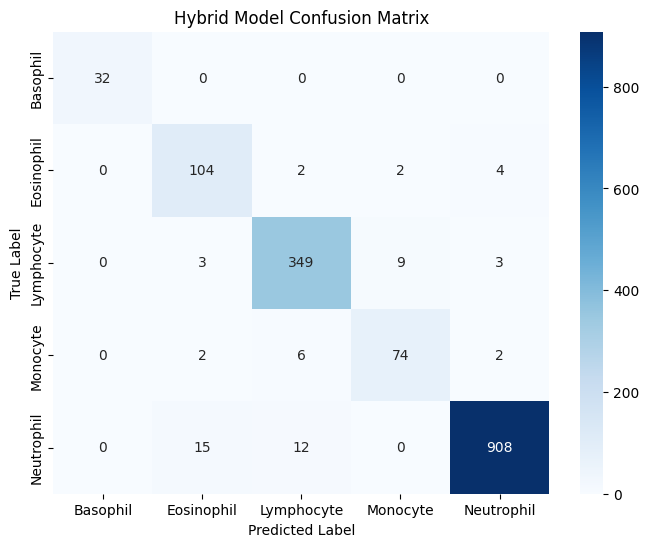

In [31]:
# Load best saved fine-tuned model
best_hybrid_model = hybrid_model

best_hybrid_model.load_state_dict(
    torch.load("best_hybrid_model_ft.pth", map_location=device)
)

best_test_loss, best_test_acc, y_pred, y_true = evaluate_model(
    best_hybrid_model,
    test_loader
)

print("Best Hybrid Test Loss:", best_test_loss)
print("Best Hybrid Test Accuracy:", best_test_acc)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid Model Confusion Matrix")
plt.show()

# ==========================================


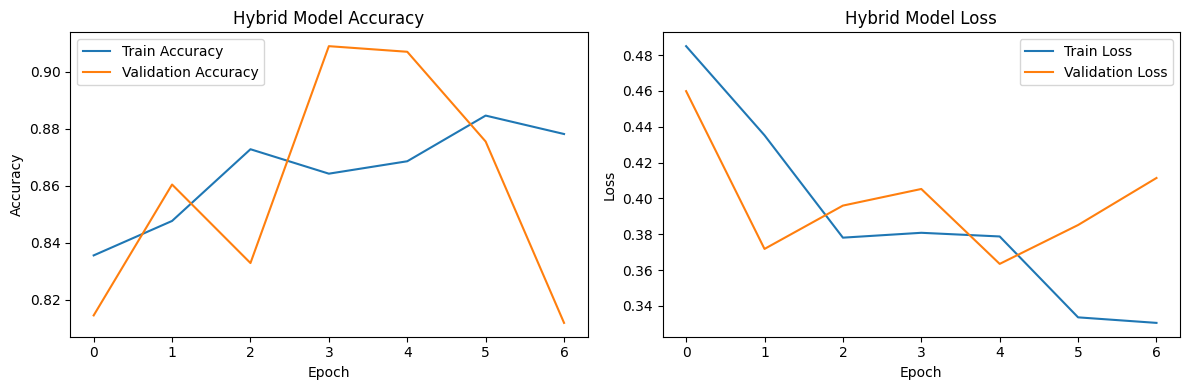

In [32]:
# 8. Plotting Training History
# ==========================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_hybrid['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid['val_accuracy'], label='Validation Accuracy')
plt.title('Hybrid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid['loss'], label='Train Loss')
plt.plot(history_hybrid['val_loss'], label='Validation Loss')
plt.title('Hybrid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


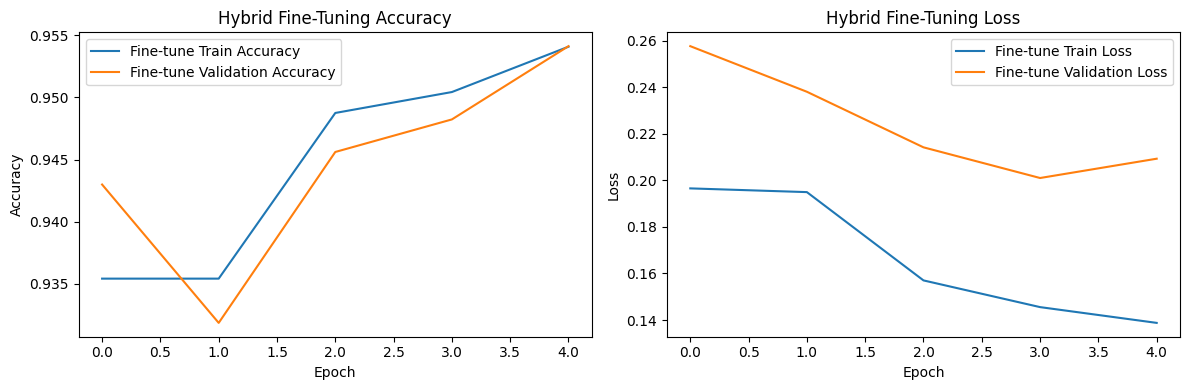

In [33]:
# Fine-tuning plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_hybrid_ft['accuracy'], label='Fine-tune Train Accuracy')
plt.plot(history_hybrid_ft['val_accuracy'], label='Fine-tune Validation Accuracy')
plt.title('Hybrid Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid_ft['loss'], label='Fine-tune Train Loss')
plt.plot(history_hybrid_ft['val_loss'], label='Fine-tune Validation Loss')
plt.title('Hybrid Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


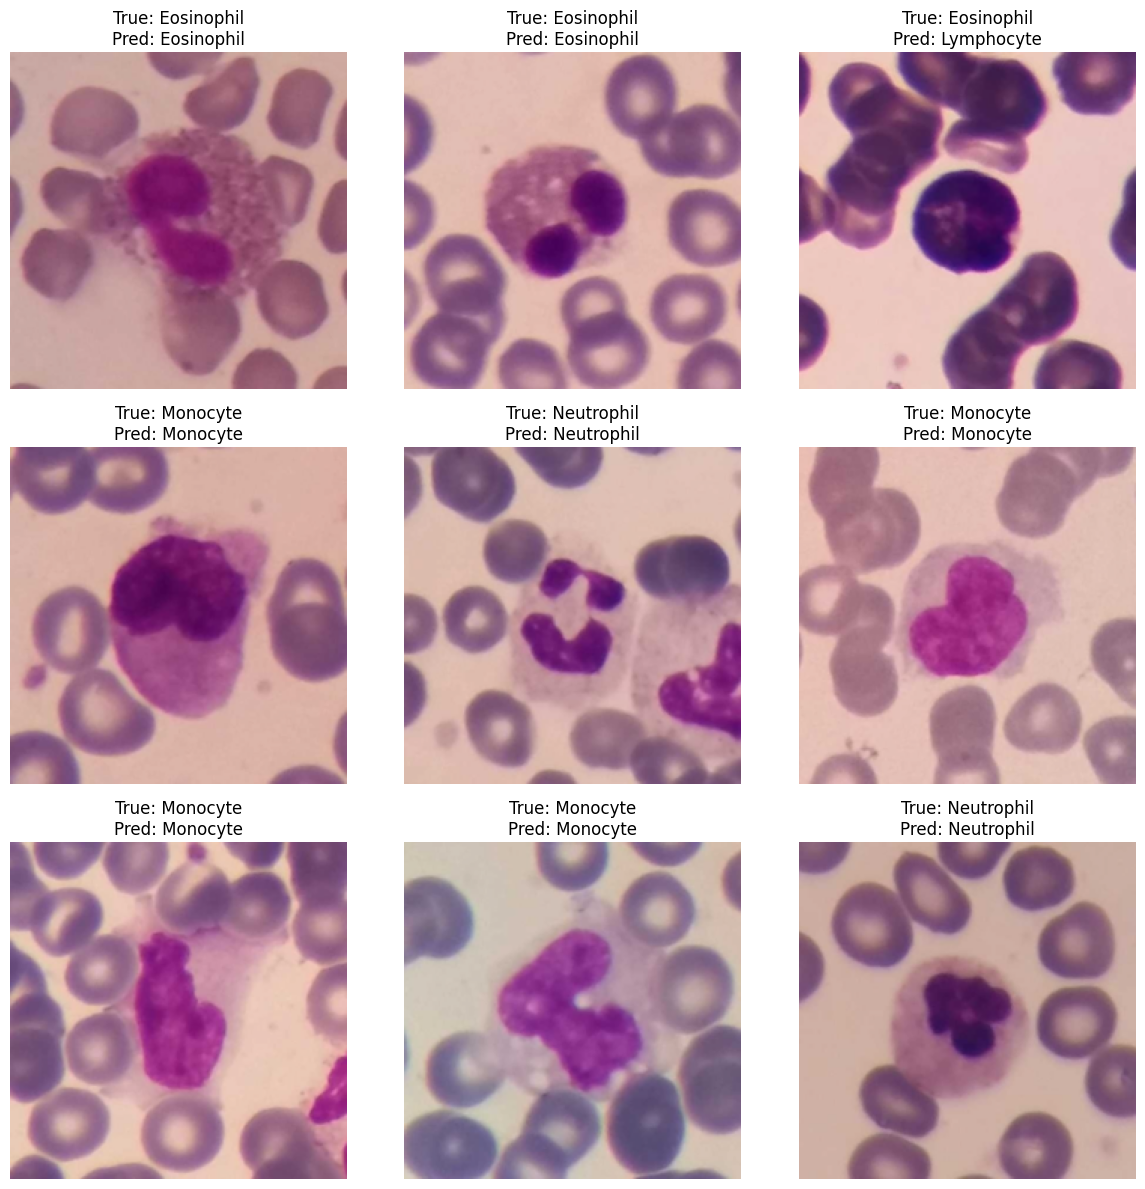

In [34]:
# Sample predictions visualization
plt.figure(figsize=(12, 12))

data_iter = iter(test_loader)
images, labels_batch = next(data_iter)

best_hybrid_model.eval()

with torch.no_grad():
    outputs = best_hybrid_model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)

    img = unnormalize_image(images[i])

    plt.imshow(img)
    plt.title(
        f"True: {class_names[labels_batch[i].item()]}\n"
        f"Pred: {class_names[preds[i].item()]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================


In [ ]:
# 9. Feature Extraction Logic


In [ ]:
# (Matching the dangling pytorch block at your file end)
# ==========================================


In [ ]:
# To extract purely the features, we bypass our fusion head.


In [35]:
# The user snippet asked to remove classifier. In our HybridModel, it's `fc2` and before.
class FeatureExtractor(nn.Module):
    def __init__(self, trained_hybrid_model):
        super(FeatureExtractor, self).__init__()

        self.eff = trained_hybrid_model.eff
        self.conv = trained_hybrid_model.conv
        self.fc1 = trained_hybrid_model.fc1

    def forward(self, x):
        eff_features = self.eff(x)
        conv_features = self.conv(x)

        fused = torch.cat((eff_features, conv_features), dim=1)

        features = self.fc1(fused)

        return features


extractor = FeatureExtractor(best_hybrid_model).to(device)
extractor.eval()


def extract_features(model, loader, device):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)

            features = model(images)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels_batch.numpy())

    return np.concatenate(all_features, axis=0), np.concatenate(all_labels, axis=0)


In [36]:
# Reusing dataloaders without augmentation for raw feature extraction
raw_train_dataset = WBCCustomDataset(
    train_imgs,
    train_labels,
    classes,
    transform=test_transform
)

raw_train_loader = DataLoader(
    raw_train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

X_train_feat, y_train_feat = extract_features(extractor, raw_train_loader, device)
X_val_feat, y_val_feat = extract_features(extractor, val_loader, device)
X_test_feat, y_test_feat = extract_features(extractor, test_loader, device)

print("Train Features:", X_train_feat.shape)
print("Val Features:", X_val_feat.shape)
print("Test Features:", X_test_feat.shape)


Train Features: (7122, 256)
Val Features: (1526, 256)
Test Features: (1527, 256)
